In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from run_exp import run_exp
import seaborn as sns
import torch.utils.benchmark as benchmark
from tqdm.notebook import tqdm, trange
import pickle
import pandas as pd
from linear_algebra_utils import *

from figures.head_view import *

from notebook_utils import load_config, load_model, load_sampler, get_task_vectors, get_cos_sim_plot, get_id_icl_error, eval_tv_id_error

torch.set_printoptions(precision=3, sci_mode=False)

%load_ext autoreload
%autoreload 2

### Remark at the beginning

When the trigger tokens are fixed, the attention pattern is not necessarily a clean Induction Head, since the TF can make use of the token embedding information. Below, we focus on the case where the trigger tokens are random.

### Instructions

To run an experiment, one can specify the length, vocabulary size, proportion of random tokens and Dirichlet prior parameter. To modify model parameters, please do it directly in the `run_exp` function.

Experiment directory:  results\frm\train_6d39ede941d90fc93e2f36e751f78fef
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
Transformer                              [128, 512]                [128, 512, 6]             --
├─Embedding: 1-1                         [128, 512]                [128, 512, 64]            384
├─ModuleList: 1-2                        --                        --                        --
│    └─TFBlock: 2-1                      [128, 512, 64]            [128, 512, 64]            --
│    │    └─Identity: 3-1                [128, 512, 64]            [128, 512, 64]            --
│    │    └─MultiHeadAttention: 3-2      [128, 512, 64]            [128, 512, 64]            16,384
│    └─TFBlock: 2-2                      [128, 512, 64]            [128, 512, 64]            --
│    │    └─Identity: 3-3                [128, 512, 64]            [128, 512, 64]            --
│    │    └─MultiHeadAttention: 3-4      [128, 512, 

eval/ICLLoss,▆▆▇█████▇▇▆▅▅▅▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/IDLoss,█▄▂▂▂▂▁▁▁▁▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/loss,█▆▄▂▂▁▁▁
train/loss,█▇▆▅▄▄▄▄▄▃▄▃▃▃▃▂▂▃▂▂▂▂▂▂▁▂▂▂▁▂▂▁▁▁▂▁▂▂▂▁
train/lr,▁▁▁▁▁▁▁▁
eval/ICLLoss,0.94284
eval/IDLoss,1.40414
eval/loss,1.31645
train/loss,1.32032
train/lr,0.0003


Starting training...
Step: 1000
Step: 2000
Step: 3000
Step: 4000
Step: 5000
Step: 6000
Step: 7000
Step: 8000
Step: 9000
Step: 10000
Step: 11000
Step: 12000
Step: 13000
Step: 14000
Step: 15000
Step: 16000
Step: 17000
Step: 18000
Step: 19000
Step: 20000
Step: 21000
Step: 22000
Step: 23000
Step: 24000
Step: 25000
Step: 26000
Step: 27000
Step: 28000
Step: 29000
Step: 30000
Step: 31000
Step: 32000
Step: 33000
Step: 34000
Step: 35000
Step: 36000
Step: 37000
Step: 38000
Step: 39000
Step: 40000
Step: 41000
Step: 42000
Step: 43000
Step: 44000
Step: 45000
Step: 46000
Step: 47000
Step: 48000
Step: 49000
Step: 50000
Step: 51000
Step: 52000
Step: 53000
Step: 54000
Step: 55000
Step: 56000
Step: 57000
Step: 58000
Step: 59000
Step: 60000
Training complete.
Loss plots saved at  results\frm\train_6d39ede941d90fc93e2f36e751f78fef\plots


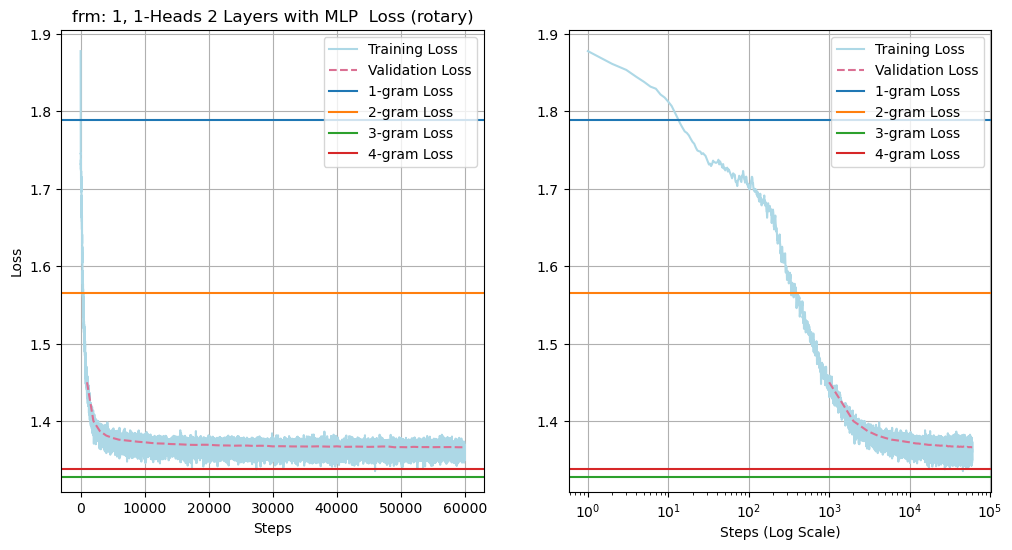

Probes plots saved at  results\frm\train_6d39ede941d90fc93e2f36e751f78fef\plots


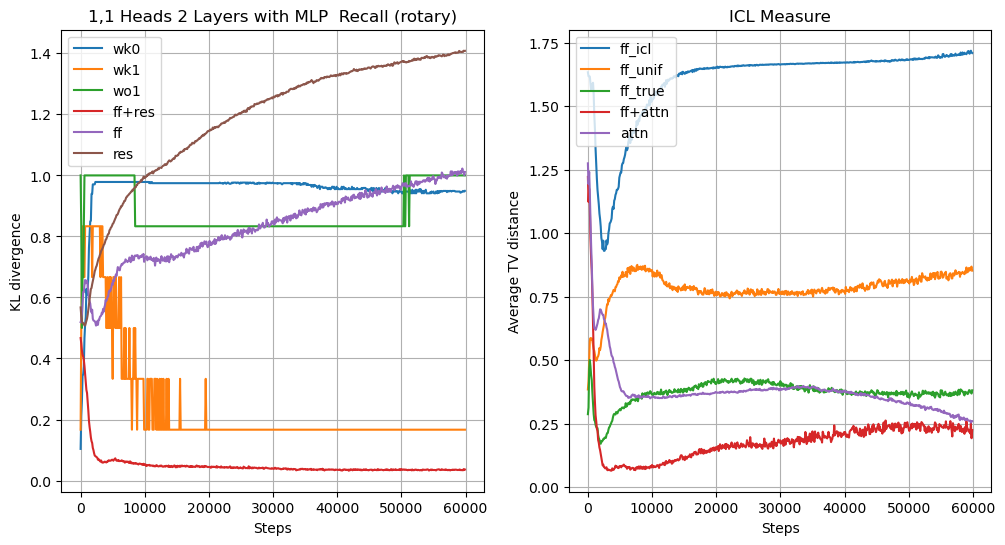

Probes plots saved at  results\frm\train_6d39ede941d90fc93e2f36e751f78fef\plots


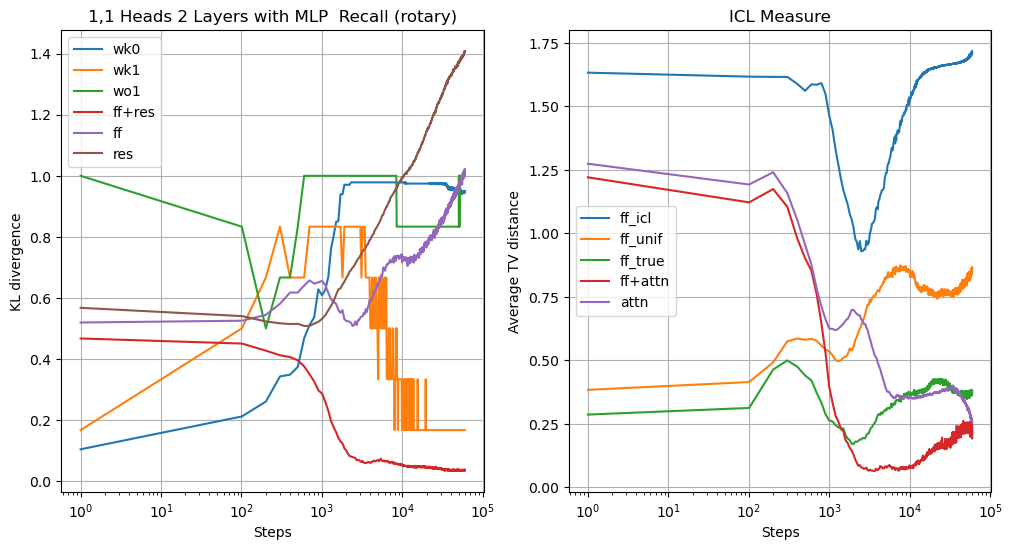

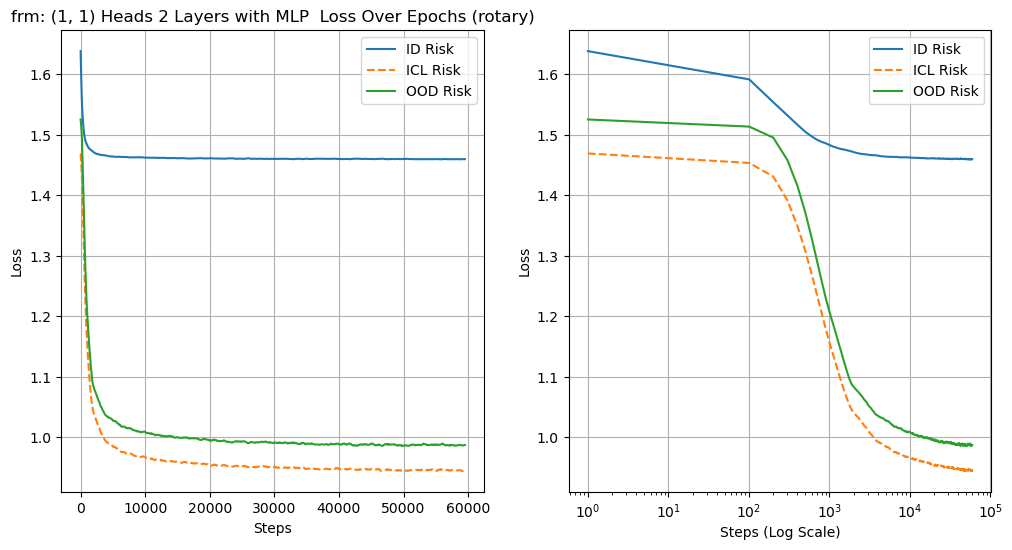

Creating images:   0%|          | 0/60 [00:00<?, ?it/s]

Creating images:   0%|          | 0/60 [00:00<?, ?it/s]

,


<IPython.core.display.Javascript object>

In [5]:
train_results, model = run_exp()

In [6]:
path_prefix = os.path.join("results", "frm")
train_folder = "train_6d39ede941d90fc93e2f36e751f78fef"
checkpoint_dir = os.path.join(path_prefix, train_folder, "checkpoints")
config_path = os.path.join(path_prefix, train_folder, "config.json")
sampler_path = os.path.join(path_prefix, train_folder, "sampler.pkl")
config = load_config(config_path)
model = load_model(checkpoint_dir, config)
sampler = load_sampler(sampler_path)

In [7]:
ffn = True
task_vecs = get_task_vectors(config, sampler, model, ffn=ffn)
kl_id_icl = get_id_icl_error(config, sampler, model)

In [8]:
kl = eval_tv_id_error(task_vecs, sampler, model, config, ffn)
print(kl.mean())

tensor(0.177)


In [9]:
print(kl_id_icl.mean())

tensor(0.259)


In [24]:
sampler.print_trans_mat()

,0,1,2,3,4,5
00,0.325,0.130,0.024,0.302,0.043,0.177
01,0.227,0.082,0.124,0.298,0.140,0.129
02,0.186,0.225,0.343,0.089,0.035,0.122
03,0.039,0.408,0.084,0.311,0.108,0.050
04,0.359,0.336,0.049,0.146,0.039,0.071
05,0.245,0.086,0.027,0.000,0.563,0.078
10,0.337,0.180,0.009,0.013,0.252,0.208
11,0.188,0.148,0.441,0.002,0.149,0.072
12,0.214,0.353,0.048,0.355,0.005,0.025
13,0.560,0.041,0.069,0.241,0.072,0.018


In [23]:
ood_batch

tensor([[3, 5, 4, 0, 3, 1, 0, 2, 1, 3, 3, 3, 2, 4, 3, 3, 5, 0, 3, 5, 1, 0, 2, 0,
         2, 0, 2, 0, 2, 1, 0, 2, 1, 2, 3, 2, 5, 4, 2, 2, 1, 0, 3, 2, 2, 0, 2, 2,
         5, 1, 5, 0, 3, 5, 0, 2, 2, 0, 2, 2, 1, 1, 2, 3, 3, 4, 3, 3, 4, 5, 1, 4,
         0, 3, 3, 1, 1, 1, 2, 1, 2, 1, 0, 2, 2, 1, 2, 0, 2, 1, 2, 3, 5, 0, 2, 5,
         4, 0, 3, 1, 1, 2, 1, 0, 2, 3, 5, 0, 3, 3, 2, 5, 4, 1, 1, 5, 1, 0, 3, 1,
         1, 2, 1, 5, 5, 4, 2, 4, 2, 4, 3, 0, 3, 3, 4, 5, 1, 0, 2, 0, 3, 3, 2, 5,
         3, 3, 4, 5, 3, 3, 2, 5, 4, 5, 0, 2, 0, 3, 5, 1, 2, 3, 2, 5, 2, 4, 3, 3,
         1, 1, 4, 2, 4, 3, 4, 3, 3, 2, 2, 1, 0, 2, 5, 4, 2, 4, 3, 2, 5, 2, 1, 2,
         3, 5, 4, 0, 3, 1, 1, 1, 1, 4, 5, 3, 3, 2, 2, 3, 3, 4, 3, 4, 2, 4, 3, 3,
         2, 5, 3, 1, 1, 2, 3, 0, 2, 2, 2, 1, 0, 2, 0, 2, 1, 2, 1, 4, 3, 3, 4, 5,
         3, 0, 3, 3, 3, 1, 1, 1, 2, 0, 2, 2, 1, 5, 0, 2, 0, 2, 1, 1, 0, 3, 1, 4,
         2, 4, 3, 3, 3, 5, 3, 3, 0, 3, 4, 3, 5, 0, 3, 1, 1, 0, 2, 0, 2, 2, 5, 2,
         4, 3, 2, 2, 2, 1, 4

In [18]:
ood_batch, ood_mask = sampler.generate(num_samples=1, mode="ood")
nn.Softmax(dim=-1)(model(ood_batch)[0][ood_mask==1])

tensor([[    0.109,     0.199,     0.322,     0.138,     0.072,     0.160],
        [    0.320,     0.166,     0.014,     0.124,     0.231,     0.144],
        [    0.135,     0.101,     0.290,     0.143,     0.164,     0.167],
        [    0.213,     0.147,     0.056,     0.329,     0.122,     0.132],
        [    0.191,     0.012,     0.197,     0.402,     0.047,     0.151],
        [    0.164,     0.008,     0.314,     0.378,     0.040,     0.097],
        [    0.114,     0.005,     0.445,     0.354,     0.027,     0.054],
        [    0.148,     0.050,     0.477,     0.197,     0.056,     0.071],
        [    0.040,     0.027,     0.731,     0.139,     0.027,     0.037],
        [    0.042,     0.005,     0.627,     0.281,     0.017,     0.029],
        [    0.025,     0.022,     0.622,     0.250,     0.019,     0.061],
        [    0.023,     0.019,     0.608,     0.259,     0.020,     0.071],
        [    0.024,     0.004,     0.656,     0.270,     0.014,     0.032],
        [   

In [10]:
effective_rank(task_vecs.numpy()), effective_rank(sampler.random_dist.task_pool)

(19.673473, 5.9091682)

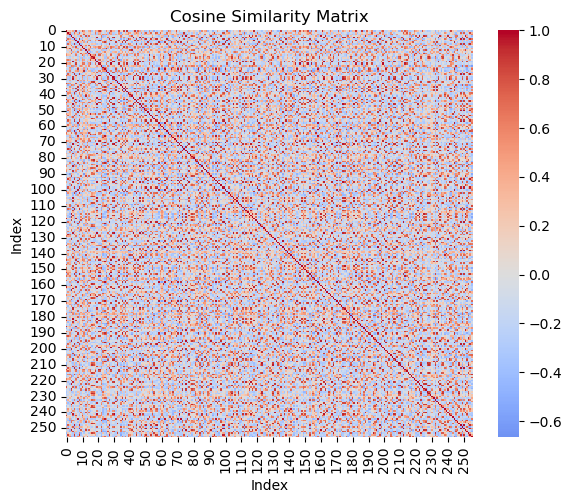

In [11]:
get_cos_sim_plot(task_vecs)

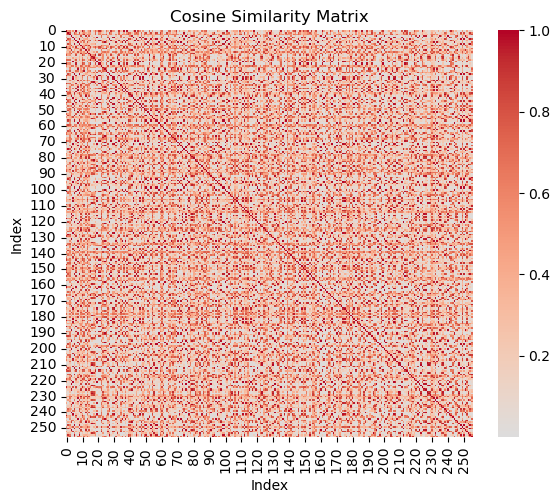

In [12]:
get_cos_sim_plot(sampler.random_dist.task_pool)

In [14]:
device = "cuda"
num_states = train_results["sampler"].num_states
OV2 = model.layers[1].MHA.value.weight.T @ model.layers[1].MHA.out.weight.T
range_toks = torch.arange(num_states).to(device)
toks = model.embed(range_toks)
task_vecs = (toks @ OV2).detach().cpu().numpy()
effective_rank(task_vecs), np.linalg.matrix_rank(task_vecs), stable_rank(task_vecs)

(5.3772855, 6, 3.352697356706975)

In [15]:
import itertools
zeros = torch.zeros(num_states) + 1e-12
kl_div = np.zeros(num_states*(num_states-1)//2)
for k, (i,j) in enumerate(list(itertools.combinations(range(num_states), 2))):
    hidden = (toks[i]/2 + toks[j]/2) @ OV2
    mlp_out = model.layers[1].mlp(hidden)
    probs = nn.Softmax(dim=-1)(model.output_layer(hidden+mlp_out))
    truth = zeros.clone()
    truth[i] = 0.5
    truth[j] = 0.5
    truth = truth / truth.sum()
    kl_div[k] = F.kl_div(truth.log(), probs.detach().cpu(), reduction="none").sum(axis=-1)
kl_div.mean()

0.2725215582177043

In [19]:
zeros = torch.zeros(num_states) + 1e-12
kl_div = np.zeros(num_states)
for i in range(num_states):
    hidden = toks[i] @ OV2
    mlp_out = model.layers[1].mlp(hidden)
    probs = nn.Softmax(dim=-1)(model.output_layer(mlp_out + hidden))
    truth = zeros.clone()
    truth[i] = 1
    truth = truth / truth.sum()
    kl_div[i] = F.kl_div(truth.log(), probs.detach().cpu(), reduction="none").sum(axis=-1)
kl_div.mean()

0.002496249658110609

In [21]:
device = "cuda"
num_states = train_results["sampler"].num_states
OV2 = model.layers[1].MHA.value.weight.T @ model.layers[1].MHA.out.weight.T
range_toks = torch.arange(num_states).to(device)
toks = model.embed(range_toks)
task_vecs = (toks @ OV2).detach().cpu().numpy()
effective_rank(task_vecs), np.linalg.matrix_rank(task_vecs), stable_rank(task_vecs)

(5.0915318, 6, 1.9765676742931142)

In [26]:
import itertools
zeros = torch.zeros(num_states) + 1e-12
kl_div = np.zeros(num_states*(num_states-1)//2)
for k, (i,j) in enumerate(list(itertools.combinations(range(num_states), 2))):
    hidden = (0.2*toks[i] + 0.8*toks[j]) @ OV2
    mlp_out = model.layers[1].mlp(hidden)
    probs = nn.Softmax(dim=-1)(model.output_layer(hidden+mlp_out))
    truth = zeros.clone()
    truth[i] = 0.2
    truth[j] = 0.8
    truth = truth / truth.sum()
    kl_div[k] = F.kl_div(truth.log(), probs.detach().cpu(), reduction="none").sum(axis=-1)
kl_div.mean()

0.22379331489404042

In [77]:
kl_div

array([ 0.831177  ,  3.11356306,  0.39721045,  0.53566277,  0.69129807,
        0.5442903 ,  0.7852571 ,  0.96849263,  0.33036125, 18.11615753,
        0.69567341,  0.68357599,  4.1506052 ,  0.90025336,  7.26335716,
        0.64480382,  0.84493744,  0.69293171,  0.70995098,  2.54974413,
        0.71980196,  0.77613467,  0.82493746,  0.96773136,  0.29574916,
        0.69351333,  0.72449064,  0.70766771,  0.09178991,  0.70459169,
        0.6371119 ,  0.65263695,  0.66384542,  1.56127381,  0.60735852,
        1.48760879,  4.80536079,  0.72956282,  4.97361469,  0.73102421,
        0.17220078,  1.84354115,  0.79076159,  1.59094787,  1.75777304])

In [74]:
kl_div

array([4.08079650e-05, 6.38935709e+00, 2.20339508e+01, 1.11417906e-08,
       1.81828580e-06, 4.00950089e-02, 2.98920851e-02, 1.12588055e-01,
       9.39161910e-05, 4.36547399e-03])

In [11]:
sampler = train_results["sampler"]
df = high_order_memory_probe_df(model)

KL divergence: 0.0129


In [19]:
df

,0,1,2,3,4,5
00,0.327571,0.160091,0.025671,0.093973,0.374585,0.018109
01,0.127859,0.030353,0.360950,0.105701,0.221463,0.153675
02,0.166662,0.138427,0.051727,0.381779,0.104890,0.156515
03,0.132061,0.287325,0.263128,0.038250,0.021876,0.257359
04,0.012073,0.421986,0.140112,0.145453,0.052524,0.227852
05,0.052428,0.297231,0.142490,0.056922,0.327382,0.123547
10,0.034875,0.093211,0.091334,0.058229,0.344885,0.377466
11,0.171119,0.003034,0.640598,0.099783,0.049319,0.036148
12,0.508127,0.009254,0.030633,0.083353,0.116126,0.252506
13,0.022670,0.553930,0.183335,0.164919,0.002186,0.072960


In [20]:
sampler.print_trans_mat()

,0,1,2,3,4,5
00,0.359,0.164,0.026,0.110,0.324,0.017
01,0.133,0.038,0.349,0.116,0.230,0.135
02,0.157,0.163,0.052,0.345,0.134,0.150
03,0.123,0.286,0.270,0.042,0.013,0.265
04,0.005,0.469,0.129,0.095,0.059,0.243
05,0.038,0.301,0.135,0.048,0.328,0.151
10,0.043,0.102,0.098,0.053,0.348,0.356
11,0.218,0.007,0.537,0.133,0.071,0.035
12,0.474,0.007,0.032,0.088,0.143,0.257
13,0.018,0.515,0.192,0.191,0.000,0.083


In [34]:
sampler.trans_mat

tensor([[0.208, 0.109, 0.022, 0.523, 0.137],
        [0.172, 0.158, 0.186, 0.079, 0.404],
        [0.001, 0.041, 0.168, 0.384, 0.407],
        [0.386, 0.004, 0.346, 0.184, 0.081],
        [0.091, 0.016, 0.340, 0.120, 0.432],
        [0.049, 0.142, 0.058, 0.726, 0.026],
        [0.004, 0.015, 0.214, 0.638, 0.129],
        [0.204, 0.011, 0.067, 0.445, 0.272],
        [0.525, 0.182, 0.106, 0.126, 0.061],
        [0.073, 0.152, 0.224, 0.216, 0.335],
        [0.642, 0.081, 0.114, 0.003, 0.160],
        [0.058, 0.463, 0.175, 0.283, 0.022],
        [0.450, 0.271, 0.165, 0.078, 0.037],
        [0.415, 0.165, 0.192, 0.187, 0.041],
        [0.127, 0.516, 0.054, 0.228, 0.074],
        [0.062, 0.060, 0.622, 0.164, 0.092],
        [0.420, 0.139, 0.431, 0.008, 0.002],
        [0.086, 0.059, 0.192, 0.054, 0.609],
        [0.168, 0.158, 0.024, 0.074, 0.575],
        [0.550, 0.103, 0.097, 0.221, 0.029],
        [0.189, 0.460, 0.046, 0.145, 0.161],
        [0.434, 0.172, 0.111, 0.057, 0.226],
        [0

In [35]:
base_probs[indices[0]+1]

tensor([0.225, 0.108, 0.027, 0.489, 0.150])

In [10]:
sampler = train_results["sampler"]
sampler.print_trans_mat()

,0,1,2,3,4
00,0.208,0.109,0.022,0.523,0.137
01,0.172,0.158,0.186,0.079,0.404
02,0.001,0.041,0.168,0.384,0.407
03,0.386,0.004,0.346,0.184,0.081
04,0.091,0.016,0.340,0.120,0.432
10,0.049,0.142,0.058,0.726,0.026
11,0.004,0.015,0.214,0.638,0.129
12,0.204,0.011,0.067,0.445,0.272
13,0.525,0.182,0.106,0.126,0.061
14,0.073,0.152,0.224,0.216,0.335


In [8]:
batch, _, trigger, _ = sampler.generate(mode="testing")
nn.Softmax(dim=-1)(model(batch)[0])[0]

tensor([[0.292, 0.236, 0.181, 0.144, 0.148],
        [0.292, 0.236, 0.181, 0.144, 0.148],
        [0.490, 0.108, 0.169, 0.042, 0.192],
        ...,
        [0.204, 0.443, 0.046, 0.154, 0.153],
        [0.181, 0.163, 0.191, 0.071, 0.395],
        [0.515, 0.182, 0.115, 0.125, 0.064]], device='cuda:0',
       grad_fn=<SelectBackward0>)

In [73]:
batch[0][128:] = torch.ones(128, dtype=torch.long, device="cuda")
logits, attns = model(batch)
nn.Softmax(dim=-1)(logits)

tensor([[[0.261, 0.210, 0.151, 0.042, 0.337],
         [0.155, 0.093, 0.177, 0.058, 0.518],
         [0.080, 0.410, 0.301, 0.135, 0.074],
         ...,
         [0.091, 0.200, 0.528, 0.043, 0.137],
         [0.091, 0.200, 0.528, 0.043, 0.137],
         [0.091, 0.199, 0.528, 0.045, 0.137]]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)

In [76]:
tensor = torch.tensor([1, 2] * (256 // 2), dtype=torch.long, device="cuda").unsqueeze(0)
probe = torch.ones((1,256), dtype=torch.long, device="cuda")
probe[0][1] = 2
logits, attns = model(batch)

In [77]:
logits, attns = model(tensor)

In [111]:
tok = torch.tensor([1], device="cuda")
emb = model.embed(tok)
OV1 = model.layers[0].MHA.value.weight.T @ model.layers[0].MHA.out.weight.T
OV2 = model.layers[1].MHA.value.weight.T @ model.layers[1].MHA.out.weight.T
emb_tran = emb + emb @ (OV1 @ OV2 + OV1 + OV2)
nn.Softmax(dim=-1)(model.output_layer(model.layers[1].mlp(emb@OV2)))

tensor([[    0.000,     1.000,     0.000,     0.000,     0.000]],
       device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [116]:
tok = torch.tensor([0,1,2,3,4], device="cuda")
emb = model.embed(tok)
nn.Softmax(dim=-1)(model.output_layer(model.layers[1].mlp(emb + emb @ (OV1 @ OV2))))

tensor([[    0.152,     0.258,     0.215,     0.114,     0.261],
        [    0.905,     0.012,     0.035,     0.040,     0.008],
        [    0.017,     0.004,     0.956,     0.022,     0.000],
        [    0.178,     0.596,     0.071,     0.012,     0.143],
        [    0.814,     0.002,     0.000,     0.182,     0.002]],
       device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [115]:
sampler.trans_mat

tensor([[0.171, 0.078, 0.178, 0.035, 0.538],
        [0.074, 0.227, 0.562, 0.014, 0.123],
        [0.043, 0.475, 0.344, 0.110, 0.028],
        [0.283, 0.187, 0.124, 0.031, 0.374],
        [0.036, 0.186, 0.023, 0.696, 0.060]], device='cuda:0')

In [114]:
nn.Softmax(dim=-1)(model.output_layer(emb + emb @ (OV1 @ OV2)))

tensor([[    0.153,     0.042,     0.113,     0.578,     0.114],
        [    0.112,     0.139,     0.260,     0.363,     0.126],
        [    0.115,     0.290,     0.001,     0.529,     0.066],
        [    0.233,     0.045,     0.285,     0.224,     0.213],
        [    0.017,     0.030,     0.928,     0.011,     0.015]],
       device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [118]:
emb1 = model.embed(torch.tensor([3], device="cuda"))
emb2 = model.embed(torch.tensor([0], device="cuda"))
emb_tran = emb2 + emb1 @ OV2 + emb1 @ OV1 @ OV2
nn.Softmax(dim=-1)(model.output_layer(model.layers[1].mlp(emb_tran) + emb_tran))

tensor([[    0.000,     0.000,     0.000,     1.000,     0.000]],
       device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [141]:
pattern = torch.tensor([2, 0, 2, 1])
n = 256
repeats = (n + len(pattern) - 1) // len(pattern)  
tensor = pattern.repeat(repeats)[:n].to("cuda").unsqueeze(0)
probs = nn.Softmax(dim=-1)(model(tensor)[0])[0][tensor[0]==2]
F.kl_div(sampler.trans_mat[2].log(), probs, reduction="none").sum(dim=-1)

tensor([0.010, 0.460, 0.002, 0.005, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
        0.001, 0.001, 0.001, 0.010, 0.001, 0.021, 0.001, 0.022, 0.002, 0.031,
        0.010, 0.059, 0.030, 0.115, 0.063, 0.163, 0.087, 0.168, 0.089, 0.172,
        0.112, 0.201, 0.169, 0.263, 0.245, 0.321, 0.298, 0.320, 0.304, 0.301,
        0.317, 0.309, 0.347, 0.318, 0.353, 0.276, 0.277, 0.222, 0.184, 0.185,
        0.143, 0.208, 0.165, 0.236, 0.184, 0.244, 0.184, 0.245, 0.197, 0.244,
        0.202, 0.249, 0.208, 0.252, 0.210, 0.246, 0.201, 0.231, 0.192, 0.214,
        0.190, 0.204, 0.188, 0.202, 0.187, 0.191, 0.174, 0.167, 0.149, 0.139,
        0.136, 0.124, 0.123, 0.110, 0.104, 0.082, 0.083, 0.055, 0.063, 0.049,
        0.073, 0.064, 0.093, 0.080, 0.098, 0.081, 0.098, 0.076, 0.095, 0.075,
        0.097, 0.089, 0.116, 0.094, 0.121, 0.096, 0.121, 0.096, 0.125, 0.099,
        0.130, 0.106, 0.136, 0.111, 0.139, 0.113, 0.140, 0.112, 0.140, 0.111,
        0.141, 0.112, 0.141, 0.118, 0.148, 0.117, 0.147, 0.116],

In [142]:
sampler.trans_mat[2]

tensor([0.043, 0.475, 0.344, 0.110, 0.028], device='cuda:0')

In [144]:
probs - sampler.trans_mat[2]

tensor([[     0.012,     -0.011,     -0.043,      0.029,      0.012],
        [     0.297,     -0.146,     -0.125,     -0.017,     -0.009],
        [     0.006,      0.018,     -0.024,     -0.002,      0.002],
        [     0.018,      0.003,     -0.026,      0.007,     -0.003],
        [     0.006,      0.015,     -0.020,     -0.001,     -0.001],
        [     0.005,      0.007,     -0.018,      0.009,     -0.003],
        [     0.006,      0.013,     -0.017,     -0.001,     -0.002],
        [     0.003,      0.007,     -0.016,      0.010,     -0.004],
        [     0.006,      0.012,     -0.015,      0.000,     -0.002],
        [     0.002,      0.007,     -0.015,      0.010,     -0.004],
        [     0.005,      0.011,     -0.014,      0.000,     -0.003],
        [     0.002,      0.006,     -0.014,      0.010,     -0.004],
        [     0.005,      0.010,     -0.013,      0.001,     -0.003],
        [     0.019,     -0.019,     -0.026,      0.031,     -0.005],
        [     0.005,

In [130]:
sampler.trans_mat

tensor([[0.171, 0.078, 0.178, 0.035, 0.538],
        [0.074, 0.227, 0.562, 0.014, 0.123],
        [0.043, 0.475, 0.344, 0.110, 0.028],
        [0.283, 0.187, 0.124, 0.031, 0.374],
        [0.036, 0.186, 0.023, 0.696, 0.060]], device='cuda:0')

In [99]:
nn.Softmax(dim=-1)(model.output_layer(model.layers[1].mlp(emb_tran)))

tensor([[    0.000,     0.996,     0.004,     0.000,     0.000]],
       device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [98]:
model.output_layer(emb_tran)

tensor([[-0.403, -1.520, -3.091,  1.967, -0.224]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [140]:
get_head_view(model, train_results, train_results["config"], trunc=0, action="view", batch=tensor)

<IPython.core.display.Javascript object>

triggers:  tensor([[0]], device='cuda:0')
outputs:  tensor([[2]], device='cuda:0')
Position:  251
--------------------------------------------------
Layer 1 KL divergence: 
--------------------
base : 0.002  ***   emb : 0.644    sa1 : 0.660    

--------------------
Layer 2 KL divergence: SA is second layer self attention applied to the output of the first layer
--------------------
sa2 : 1.025    out1 : 0.413    sa2+out1 : 0.002  ***   

--------------------------------------------------


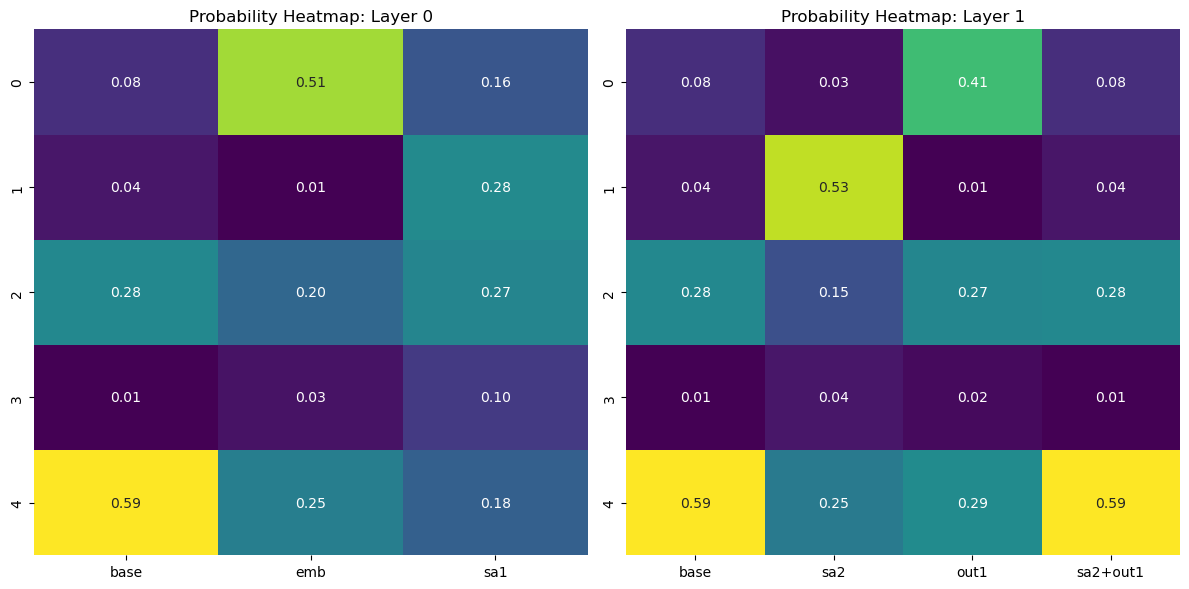

In [8]:
get_memory(model, tok=1)

triggers:  tensor([[10,  8, 12]], device='cuda:0')
outputs:  tensor([[ 8,  6, 10]], device='cuda:0')
triggers:  tensor([[4, 6, 1]], device='cuda:0')
outputs:  tensor([[13, 14, 11]], device='cuda:0')
Position:  113
--------------------------------------------------
Layer 1 KL divergence: 
--------------------
base : 0.001  ***   emb : 0.225  *   ffn(emb) : 0.190  *   ffn(emb)+emb : 0.085  **
sa1 : 0.377    ffn(sa1) : 0.415    

--------------------
Layer 2 KL divergence: SA is second layer self attention applied to the output of the first layer
--------------------
sa2 : 0.251  *   out1 : 0.377    sa2+out1 : 0.352    ffn(sa2) : 0.949 
ffn(sa2+out1) : 0.625    ffn(sa2+out1)+sa2 : 0.153  *   ffn(sa2+out1)+out1 : 0.297  *   

--------------------------------------------------


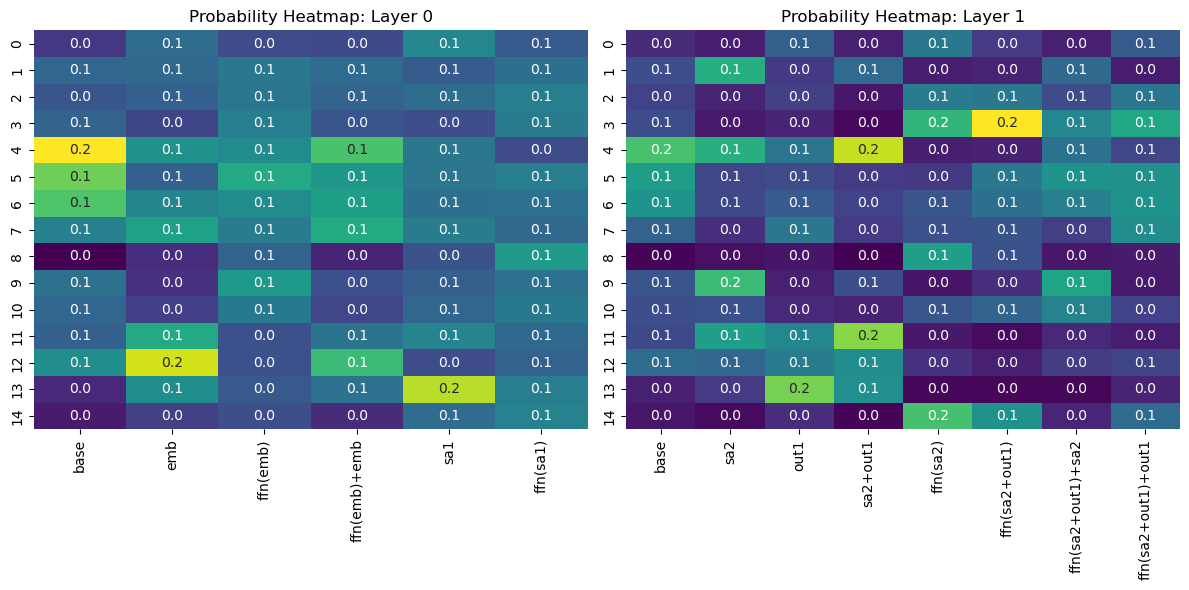

In [92]:
get_memory(model, tok=3)

In [18]:
tok = 4
target = (1-rho)*sampler.trans_mat+rho*torch.ones((VOC_SIZE, VOC_SIZE), device="cuda") / VOC_SIZE
F.kl_div(target[tok].log(), nn.Softmax(dim=-1)(model(batch)[0])[batch==tok][0], reduction="sum")

tensor(0.007, device='cuda:0', grad_fn=<SumBackward0>)

In [19]:
F.kl_div(sampler.trans_mat[tok].log(), nn.Softmax(dim=-1)(model(batch)[0])[batch==tok][0], reduction="sum")

tensor(0.054, device='cuda:0', grad_fn=<SumBackward0>)

### Loading Checkpoints

One can load checkpoints as follows.

In [4]:
with open('checkpoints/bietti/20250221_1235/train_results.pkl', 'rb') as file:
    train_results = pickle.load(file)
config = train_results["config"]
model_ckpt = Transformer(config)
checkpoint = torch.load("checkpoints/bietti/20250221_1235/model_49200.pt", weights_only=True)
model_ckpt.load_state_dict(checkpoint)
model_ckpt = model_ckpt.to(config.device)

#### Access model parameters

In [5]:
OV1 = model_ckpt.layers[0].MHA.value.weight.T @ model_ckpt.layers[0].MHA.out.weight.T
OV2 = model_ckpt.layers[1].MHA.value.weight.T @ model_ckpt.layers[1].MHA.out.weight.T
U = model_ckpt.output_layer.weight.T
Wkey = model_ckpt.layers[1].mlp[0].weight.T 
Wval = model_ckpt.layers[1].mlp[2].weight.T 
range_toks = torch.arange(config.vocab_size).to(config.device)
toks = model_ckpt.embed(range_toks) # (N, D)
(toks @ OV1 @ U).norm(dim=-1)

tensor([1.182, 0.811, 0.810, 1.041, 1.014, 1.011, 0.964, 1.063, 0.944, 1.074],
       device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)

In [6]:
(toks @ OV1 @ OV2 @ U).norm(dim=-1)

tensor([0.981, 2.307, 0.995, 1.219, 0.959, 1.542, 1.243, 1.433, 1.942, 2.302],
       device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)

In [24]:
(Wval @ U).topk(2, dim=0).indices.T

tensor([[ 29,   0],
        [ 79, 100],
        [ 73,  43],
        [124,  19],
        [ 58,  71],
        [ 89,  64],
        [ 17,  93],
        [ 76,  53],
        [ 30, 126],
        [ 38,  57]], device='cuda:0')

In [48]:
nn.Softmax(dim=-1)((toks[2] + toks.mean(0) @ OV2) @ U + nn.ReLU()((toks[2] + toks.mean(0) @ OV2) @ Wkey) @ (Wval @ U))

tensor([0.127, 0.050, 0.003, 0.301, 0.064, 0.017, 0.120, 0.016, 0.020, 0.282],
       device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [8]:
sampler = train_results["sampler"]
config = train_results["config"]
sampler.trans_mat[2]

tensor([0.050, 0.398, 0.378, 0.100, 0.073], device='cuda:0')

In [118]:
# Generate a batch of inputs and targets
batch = sampler.modified(token=2)
targets = batch[:, 1:].reshape(-1)
print(batch.shape)

# Forward pass
outputs, _ = model(batch)
outputs = outputs[:, :-1, :].reshape(-1, config.vocab_size)
criterion = nn.CrossEntropyLoss()
loss = criterion(outputs, targets)

# Compute gradients w.r.t. model parameters without updating them
gradients = torch.autograd.grad(loss, model.parameters(), create_graph=True)

Modified transition matrix for token:  tensor([0.002, 0.061, 0.568, 0.165, 0.204], device='cuda:0')
Old transition matrix for token:  tensor([0.050, 0.398, 0.378, 0.100, 0.073], device='cuda:0')
torch.Size([2205, 128])


<Axes: >

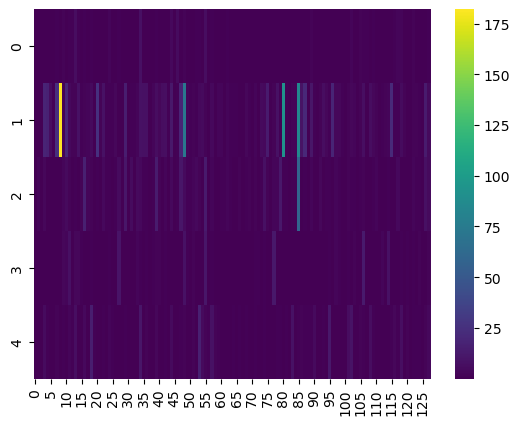

In [119]:
Wval = model.layers[1].mlp[2].weight.detach().cpu().numpy()
Wvalgrad = gradients[11].detach().cpu().numpy()
U = model.output_layer.weight.detach().cpu().numpy()
Ugrad = gradients[13].detach().cpu().numpy()
sns.heatmap(np.abs(U@Wvalgrad + Ugrad@Wval) / np.abs(U@Wval+1e-2), annot=False, cmap='viridis', fmt='.2f', cbar=True)

<Axes: >

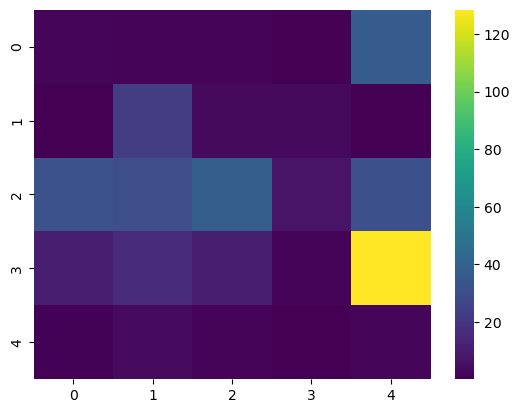

In [120]:
toks = model.embed(torch.arange(config.vocab_size, device=config.device)).detach().cpu().numpy()
sns.heatmap(np.abs(toks@Ugrad.T)/np.abs(toks@U.T+1e-2), annot=False, cmap='viridis', fmt='.2f', cbar=True)

<Axes: >

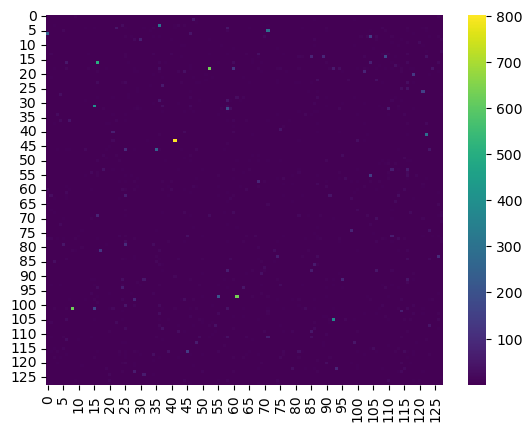

In [116]:
V2 = model.layers[1].MHA.value.weight.detach().cpu().numpy()
V2grad = gradients[7].detach().cpu().numpy()
O2 = model.layers[1].MHA.out.weight.detach().cpu().numpy()
O2grad = gradients[8].detach().cpu().numpy()
sns.heatmap(np.clip(np.abs(V2.T@O2grad.T+V2grad.T@O2.T)/np.abs(V2.T@O2.T+np.mean(V2.T@O2.T)), a_min=0, a_max=1000), annot=False, cmap='viridis', fmt='.2f', cbar=True)

<Axes: >

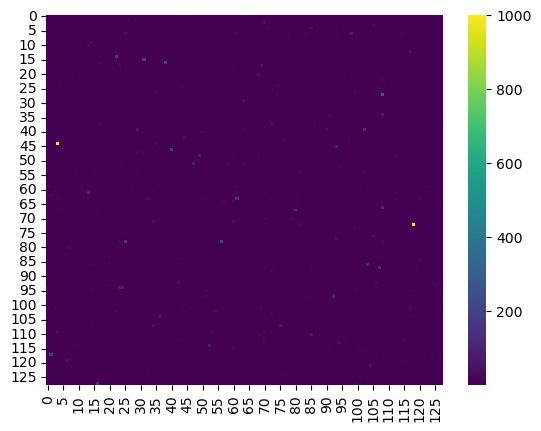

In [117]:
V1 = model.layers[0].MHA.value.weight.detach().cpu().numpy()
V1grad = gradients[3].detach().cpu().numpy()
O1 = model.layers[0].MHA.out.weight.detach().cpu().numpy()
O1grad = gradients[4].detach().cpu().numpy()
sns.heatmap(np.clip(np.abs(V1.T@O1grad.T+V1grad.T@O1.T)/np.abs(V1.T@O1.T+np.mean(V1.T@O1.T)), a_min=0, a_max=1000), annot=False, cmap='viridis', fmt='.2f', cbar=True)